#Task 4: In-Memory Hierarchical Navigable Small World (HNSW) Vector Indexing from Scratch
###Objective

Develop a high-speed vector retrieval engine to support semantic search and real-time knowledge retrieval without utilizing pre-built database drivers.

###Technologies / Tools Used
Python,
NetworkX,
SciPy,
NumPy

#Step 1: Import Required Libraries

Import the libraries required for creating vectors, calculating similarity, creating graphs, and visualization.

In [1]:
# Import NumPy for vector operations
import numpy as np

# Import NetworkX for graph creation
import networkx as nx

# Import cosine distance from SciPy
from scipy.spatial.distance import cosine

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Set random seed for consistent results
np.random.seed(42)

#Step 2: Create Sample Vectors

Create a collection of random vectors that represent our data.

Each vector can be considered an embedding of a document, sentence, image, or other data.

In [2]:
# Number of vectors
num_vectors = 30

# Dimension of each vector
dimension = 4

# Create random vectors
vectors = np.random.rand(
    num_vectors,
    dimension
)

print("Number of vectors:", num_vectors)
print("Vector dimension:", dimension)
print("\nFirst 5 vectors:")
print(vectors[:5])

Number of vectors: 30
Vector dimension: 4

First 5 vectors:
[[0.37454012 0.95071431 0.73199394 0.59865848]
 [0.15601864 0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497 0.18340451]
 [0.30424224 0.52475643 0.43194502 0.29122914]]


#Step 3: Calculate Cosine Similarity

HNSW uses distances between vectors to determine which nodes should be connected.

We will use cosine similarity.

Cosine similarity measures how similar two vectors are based on their direction.

###Formula
Cosine Similarity = 1 - Cosine Distance

In [3]:
# Function to calculate cosine similarity
def cosine_similarity(a, b):

    # scipy cosine() returns cosine distance
    distance = cosine(a, b)

    # Convert distance into similarity
    similarity = 1 - distance

    return similarity


# Test cosine similarity
similarity = cosine_similarity(
    vectors[0],
    vectors[1]
)

print("Cosine Similarity:", similarity)

Cosine Similarity: 0.6156903428844458


#Step 4: Assign Hierarchical Levels to Vectors

HNSW uses multiple layers.

Higher layers contain fewer nodes, while lower layers contain more nodes.

We assign levels using a probability-based method.

In [4]:
# Maximum number of layers
max_layers = 3

# Store the level of each vector
levels = []

for i in range(num_vectors):

    # Generate a random number
    random_value = np.random.rand()

    # Probability-based level assignment
    level = int(
        -np.log(random_value)
    )

    # Limit the maximum level
    level = min(
        level,
        max_layers - 1
    )

    levels.append(level)

print("Assigned levels:")
print(levels)

print("\nNumber of nodes in each layer:")

for layer in range(max_layers):

    count = sum(
        level >= layer
        for level in levels
    )

    print(
        "Layer",
        layer,
        ":",
        count,
        "nodes"
    )

Assigned levels:
[0, 0, 1, 2, 1, 0, 0, 0, 2, 0, 0, 1, 2, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 2, 0, 0, 2, 1]

Number of nodes in each layer:
Layer 0 : 30 nodes
Layer 1 : 15 nodes
Layer 2 : 5 nodes


#Step 5: Create the Multi-Layer HNSW Graph

Create one graph for each HNSW layer.

The same vector can appear in multiple layers depending on its assigned level.

In [5]:
# Create graphs for each layer
graphs = [
    nx.Graph()
    for _ in range(max_layers)
]

# Add nodes to appropriate layers
for node in range(num_vectors):

    # Add the node to every layer up to its level
    for layer in range(levels[node] + 1):

        graphs[layer].add_node(node)

print("Number of nodes in each layer:")

for layer, graph in enumerate(graphs):

    print(
        "Layer",
        layer,
        ":",
        graph.number_of_nodes(),
        "nodes"
    )

Number of nodes in each layer:
Layer 0 : 30 nodes
Layer 1 : 15 nodes
Layer 2 : 5 nodes


#Step 6: Connect Nearby Vectors

Connect each node to its nearest neighbors in every layer.

This creates the proximity graph used for searching.

In [6]:
# Number of neighbors for each node
M = 4

# Build connections in every layer
for layer in range(max_layers):

    graph = graphs[layer]

    for node in graph.nodes:

        # Calculate similarity with other nodes
        similarities = []

        for other in graph.nodes:

            if node == other:
                continue

            similarity = cosine_similarity(
                vectors[node],
                vectors[other]
            )

            similarities.append(
                (other, similarity)
            )

        # Sort by similarity
        similarities.sort(
            key=lambda x: x[1],
            reverse=True
        )

        # Connect to the best neighbors
        for other, similarity in similarities[:M]:

            graph.add_edge(
                node,
                other,
                weight=similarity
            )

print("HNSW graph created.")

for layer, graph in enumerate(graphs):
    print(
        "Layer",
        layer,
        "Edges:",
        graph.number_of_edges()
    )

HNSW graph created.
Layer 0 Edges: 76
Layer 1 Edges: 39
Layer 2 Edges: 10


#Step 7: Create a Query Vector

Create a query vector that we want to search against the HNSW index.

The search will find the vectors most similar to this query.

In [7]:
# Create a random query vector
query = np.random.rand(dimension)

print("Query Vector:")
print(query)

Query Vector:
[0.90826589 0.23956189 0.14489487 0.48945276]


#Step 8: Perform Hierarchical Search

Search starts from the highest layer and moves toward the lowest layer.

At each layer, we move to a neighboring node if it is more similar to the query.

This reduces the number of nodes that need to be examined.

In [8]:
# Find the highest layer
highest_layer = max(
    range(max_layers),
    key=lambda layer: len(graphs[layer].nodes)
)

# Start from a node in the highest layer
current_node = list(
    graphs[highest_layer].nodes
)[0]

# Store visited nodes
visited = set()

# Search from highest layer to lowest layer
for layer in range(
    max_layers - 1,
    -1,
    -1
):

    graph = graphs[layer]

    # Make sure current node exists in this layer
    if current_node not in graph:
        current_node = list(graph.nodes)[0]

    improved = True

    # Greedy search
    while improved:

        improved = False

        visited.add(current_node)

        current_similarity = cosine_similarity(
            query,
            vectors[current_node]
        )

        for neighbor in graph.neighbors(
            current_node
        ):

            neighbor_similarity = cosine_similarity(
                query,
                vectors[neighbor]
            )

            # Move to a better neighbor
            if neighbor_similarity > current_similarity:

                current_node = neighbor
                current_similarity = neighbor_similarity

                improved = True

                break


print("Search completed.")
print("Best candidate node:", current_node)
print(
    "Similarity:",
    cosine_similarity(
        query,
        vectors[current_node]
    )
)

Search completed.
Best candidate node: 22
Similarity: 0.9710345770238943


#Step 9: Generate Similarity Rankings

After reaching the candidate node, calculate similarities and return the most similar vectors.

This gives us the final semantic-search ranking.

In [9]:
# Calculate similarity between query and every vector
results = []

for node in range(num_vectors):

    similarity = cosine_similarity(
        query,
        vectors[node]
    )

    results.append(
        (node, similarity)
    )

# Sort results by similarity
results.sort(
    key=lambda x: x[1],
    reverse=True
)

# Display top 5 results
print("Top 5 Similar Vectors:")

for node, similarity in results[:5]:

    print(
        "Vector:",
        node,
        "Similarity:",
        round(similarity, 4)
    )

Top 5 Similar Vectors:
Vector: 22 Similarity: 0.971
Vector: 5 Similarity: 0.9684
Vector: 26 Similarity: 0.9637
Vector: 3 Similarity: 0.9625
Vector: 19 Similarity: 0.8978


#Step 10: Visualize the HNSW Graph

Visualize the bottom HNSW layer.

The nodes represent vectors and the edges represent connections between nearby vectors.

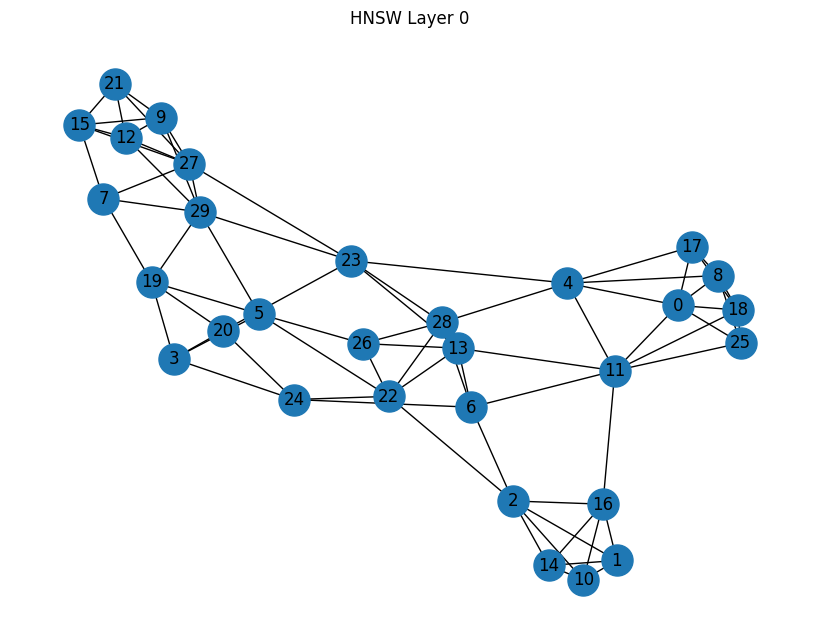

In [10]:
# Select the bottom layer
graph = graphs[0]

# Create graph layout
positions = nx.spring_layout(
    graph,
    seed=42
)

# Draw the graph
plt.figure(figsize=(8, 6))

nx.draw(
    graph,
    positions,
    with_labels=True,
    node_size=500
)

plt.title("HNSW Layer 0")

plt.show()

#Step 11: Visualize the Number of Nodes per Layer

Show how the number of nodes decreases as we move to higher layers.

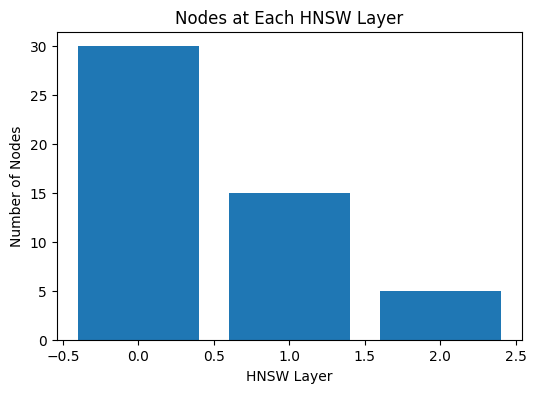

In [11]:
# Count nodes in each layer
layer_counts = []

for layer in range(max_layers):

    layer_counts.append(
        graphs[layer].number_of_nodes()
    )

# Plot layer sizes
plt.figure(figsize=(6, 4))

plt.bar(
    range(max_layers),
    layer_counts
)

plt.xlabel("HNSW Layer")
plt.ylabel("Number of Nodes")
plt.title("Nodes at Each HNSW Layer")

plt.show()

#Conclusion

The HNSW vector indexing system was implemented from scratch using Python, NumPy, SciPy, and NetworkX. The implementation creates multiple graph layers, assigns nodes using probability-based levels, connects nearby vectors using cosine similarity, performs hierarchical search from higher to lower layers, and produces similarity rankings.

The visualization also shows the structure of the HNSW graph and the distribution of nodes across its layers. This follows the task requirement to construct a multi-tier proximity graph and perform hierarchical vector retrieval